First few rows of the dataset:
   sepal length (cm)  sepal width (cm)  target
0                5.1               3.5       0
1                4.9               3.0       0
2                4.7               3.2       0
3                4.6               3.1       0
4                5.0               3.6       0

Test Loss: 0.0122, Test Accuracy: 100.00%
1/1 [==============================] - 0s 105ms/step


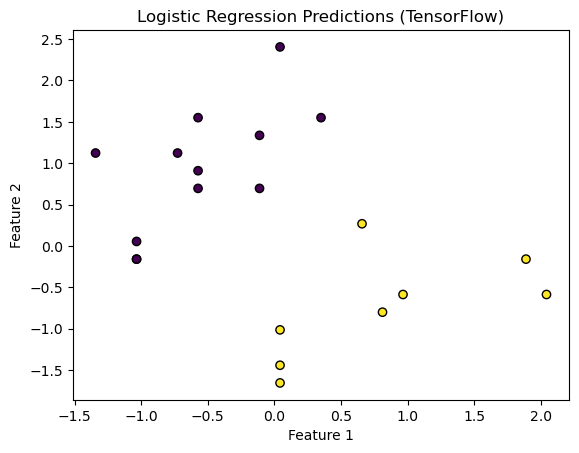

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Step 1: Load the Dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# We will consider only two classes for binary classification
X = X[y != 2]  # Taking only class 0 and class 1
y = y[y != 2]

# Select only the first two features for easier visualization
X = X[:, :2]  # Use only the first two features

# Convert to a DataFrame for easier handling
df = pd.DataFrame(data=X, columns=iris.feature_names[:2])  # Use only the first two features
df['target'] = y

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Step 2: Preprocess the Data
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 3: Build the Logistic Regression Model using TensorFlow
class LogisticRegressionModel(tf.keras.Model):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.dense = tf.keras.layers.Dense(1, activation='sigmoid')  # Single output for binary classification

    def call(self, inputs):
        return self.dense(inputs)

# Step 4: Compile the Model
model = LogisticRegressionModel()
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy',  # Use binary cross-entropy as the loss function
              metrics=['accuracy'])

# Step 5: Train the Model
model.fit(X_train, y_train, epochs=1000, verbose=0)

# Step 6: Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Loss: {loss:.4f}, Test Accuracy: {accuracy * 100:.2f}%')

# Step 7: Make Predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Step 8: Visualize Predictions
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_classes, cmap='viridis', edgecolor='k', marker='o')
plt.title('Logistic Regression Predictions (TensorFlow)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


First few rows of the dataset:
   sepal length (cm)  sepal width (cm)  target
0                5.1               3.5       0
1                4.9               3.0       0
2                4.7               3.2       0
3                4.6               3.1       0
4                5.0               3.6       0
Epoch 1/1000
3/3 [==============================] - 1s 5ms/step - loss: 1.3690 - accuracy: 0.0875
Epoch 2/1000
3/3 [==============================] - 0s 5ms/step - loss: 1.2075 - accuracy: 0.0875
Epoch 3/1000
3/3 [==============================] - 0s 4ms/step - loss: 1.0652 - accuracy: 0.1125
Epoch 4/1000
3/3 [==============================] - 0s 4ms/step - loss: 0.9453 - accuracy: 0.1625
Epoch 5/1000
3/3 [==============================] - 0s 4ms/step - loss: 0.8368 - accuracy: 0.2750
Epoch 6/1000
3/3 [==============================] - 0s 4ms/step - loss: 0.7452 - accuracy: 0.4875
Epoch 7/1000
3/3 [==============================] - 0s 4ms/step - loss: 0.6680 - accuracy: 0.6000
E

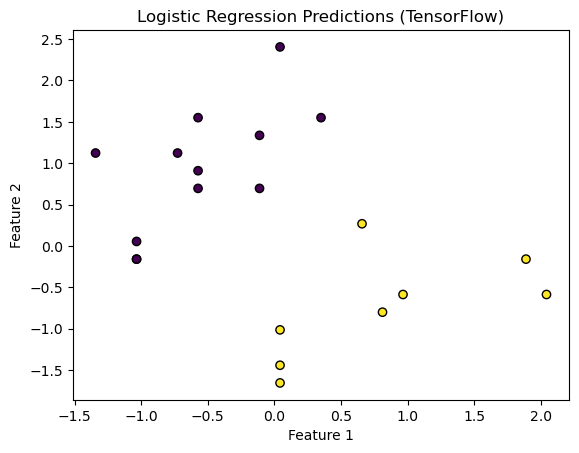

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Step 1: Load the Dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# We will consider only two classes for binary classification
X = X[y != 2]  # Taking only class 0 and class 1
y = y[y != 2]

# Select only the first two features for easier visualization
X = X[:, :2]  # Use only the first two features

# Convert to a DataFrame for easier handling
df = pd.DataFrame(data=X, columns=iris.feature_names[:2])  # Use only the first two features
df['target'] = y

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Step 2: Preprocess the Data
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 3: Build the Logistic Regression Model using TensorFlow
class LogisticRegressionModel(tf.keras.Model):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.dense = tf.keras.layers.Dense(1, activation='sigmoid')  # Single output for binary classification

    def call(self, inputs):
        return self.dense(inputs)

# Step 4: Compile the Model
model = LogisticRegressionModel()
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy',  # Use binary cross-entropy as the loss function
              metrics=['accuracy'])

# Step 5: Train the Model and display loss and accuracy at each epoch
history = model.fit(X_train, y_train, epochs=1000, verbose=1)

# Step 6: Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Loss: {loss:.4f}, Test Accuracy: {accuracy * 100:.2f}%')

# Step 7: Make Predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Step 8: Visualize Predictions
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_classes, cmap='viridis', edgecolor='k', marker='o')
plt.title('Logistic Regression Predictions (TensorFlow)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
